# PLAN NA TESTING METRYKI

- z macierzy korelacji wybrać lambdy ktore wyszly
- zrobić narzedzie które liczy score
- wygenerować graf - recznie(?) wygenerowac jakąś wizulizacje jego, jedna lepsza, jedna wyraźnie gorsza i popatrzeć czy metryka zwraca wynik który ma sens 
- w komponentach dac tez wersje komponentow bez zmian z artykulu
- porównać wyniki na 3 kategoriach grafu (BA ER SBM) i pomysleć czy przy wybieraniu lambd brać pod uwagę rodzaj tego grafu

In [1]:
import sys
from pathlib import Path

# sys.path.insert(0,str(Path(r'C:\Users\ku51015\CHMURA\mystuff\Graph-Vizualisation-Rating-Metric').resolve()))
sys.path.insert(0,str(Path(r'C:\Users\Kinga\Desktop\MAGISTERKA\Graph-Vizualisation-Rating-Metric-3').resolve()))

from graph_generating_script import *
from graph_metric_script import *
import matplotlib.pyplot as plt
import igraph as ig
import numpy as np
import pickle
import seaborn as sns
from tqdm import tqdm

### connect all dataframes and generate coorelation for all

In [2]:


def calculate_lambdas_from_score_annotations(annotations_path, category):
    # annotations = pd.read_excel('randoms_ER_annotations_scores.xlsx')
    annotations = pd.read_excel(annotations_path)
    import os 
    posdf_dir = category + '/pos_dfs'
    graph_dir = category + '/graph_objects'


    calculated_components_df = pd.DataFrame(columns=['posdf_id', 'score', 
                                                    'node_distribution', 'node_distribution_raw', 
                                                    'distance_to_borderlines', 'distance_to_borderlines_raw', 
                                                    'edge_length_sum', 'edge_length_sum_raw', 
                                                    'edge_node_distance_contribution','edge_node_distance_contribution_raw', 
                                                    'count_edge_crossings',  'count_edge_crossings_raw',
                                                    'communities_closeness', 'sum_of_angles', 'symmetry'])

    # Iterate through files in the posdf_dir
    skip_layouts = ['lgl']

    for posdf_file in tqdm(os.listdir(posdf_dir)):

        if posdf_file.split('_')[1].split('.')[0] not in skip_layouts:
            # reading data

            if posdf_file.endswith('.csv'):
                posdf = pd.read_csv(os.path.join(posdf_dir, posdf_file))
                # print(f'Loaded {posdf_file}')

            graph_id = posdf_file.split('_')[0]
            layout = posdf_file.split('.')[0]
            if int(graph_id) < 10:
                layout = layout[2:]
            else:
                layout = layout[3:]
            score = annotations[annotations['graph_id'] == int(graph_id)][layout].values[0]


            graph_file = 'graph_' + graph_id + '.pkl' 
            with open(os.path.join(graph_dir, graph_file), 'rb') as f:
                G = pickle.load(f)
                
            components_dict = {
                'posdf_id': posdf_file,
                'score': score,
                'node_distribution': node_distribution(posdf),
                'node_distribution_raw': node_distribution_raw(posdf),
                'distance_to_borderlines': distance_to_borderlines(posdf),
                'distance_to_borderlines_raw': distance_to_borderlines_raw(posdf),
                'edge_length_sum': edge_length_sum(G, posdf),
                'edge_length_sum_raw': edge_length_sum_raw(G, posdf),
                'edge_node_distance_contribution': edge_node_distance_contribution(G, posdf)[0],
                'edge_node_distance_contribution_raw': edge_node_distance_contribution_raw(G, posdf)[0],

                'count_edge_crossings': count_edge_crossings(G, posdf),
                'count_edge_crossings_raw': count_edge_crossings_raw(G, posdf),

                'communities_closeness' : intra_cluster_distance(G, posdf)['overall_sum'],
                'sum_of_angles' : sum_of_angles(G, posdf),
                'symmetry' : measure_graph_symmetry(G, posdf)
            }
            new_row_df = pd.DataFrame([components_dict])
            calculated_components_df = pd.concat([calculated_components_df, new_row_df], ignore_index=True)
            calculated_components_df_numeric = calculated_components_df.drop(columns=['posdf_id'])

    # Calculate the correlation matrix
    correlation_matrix = calculated_components_df_numeric.corr()

    # Extract the correlation of all values to 'score'
    score_correlation = correlation_matrix.loc[['score']]
    score_correlation['category'] = category
    # score_correlation = pd.DataFrame(score_correlation)

    # print(type(score_correlation))
    # Generate a heatmap for the 'score' correlation

    
    # ============
    #for drawing the heatma

    # plt.figure(figsize=(20, 1.5))  # Adjust the figure size as needed
    # sns.heatmap(score_correlation, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
    # plt.xticks(rotation=60, ha='right')

    # plt.title('Correlation with Score')
    # plt.show()

    return score_correlation

In [3]:
WS_corrs = calculate_lambdas_from_score_annotations('WS\WS_annotations_scores.xlsx','WS')
WS_corrs.to_csv('lambdas\WS_corrs.csv', index=False)
RGG_corrs = calculate_lambdas_from_score_annotations('RGG\RGG_annotations_scores.xlsx','RGG')
RGG_corrs.to_csv('lambdas\RGG_corrs.csv', index=False)
ER_corrs = calculate_lambdas_from_score_annotations('ER\ER_annotations_scores.xlsx','ER')
ER_corrs.to_csv('lambdas\ER_corrs.csv', index=False)
BA_corrs = calculate_lambdas_from_score_annotations('BA\BA_annotations_scores.xlsx','BA')
BA_corrs.to_csv('lambdas\BA_corrs.csv', index=False)

100%|██████████| 126/126 [00:30<00:00,  4.07it/s]


In [5]:
all_cats_corrs = pd.concat([WS_corrs, RGG_corrs, ER_corrs, BA_corrs], ignore_index=True)
all_cats_corrs

,score,node_distribution,node_distribution_raw,distance_to_borderlines,distance_to_borderlines_raw,edge_length_sum,edge_length_sum_raw,edge_node_distance_contribution,edge_node_distance_contribution_raw,count_edge_crossings,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry,category
0,1.0,-0.426195,-0.343486,0.132005,0.139994,0.242659,0.198405,-0.281927,-0.337924,-0.154532,-0.221363,0.314774,0.044435,-0.500937,WS
1,1.0,-0.442839,-0.386970,0.130822,0.131458,0.090325,0.121934,0.130819,0.129815,-0.259799,-0.303147,0.319379,0.084007,-0.264608,RGG
2,1.0,-0.351749,-0.419731,0.132129,0.134250,0.359109,0.305512,0.011394,-0.188299,-0.116133,-0.151995,0.395453,0.091560,-0.471782,ER
3,1.0,-0.438908,-0.295487,0.493136,0.513931,0.188714,0.152569,-0.056300,-0.230325,-0.065893,-0.138188,0.295741,0.054358,-0.514301,BA


In [ ]:
all_cats_corrs.set_index('category', inplace=True)


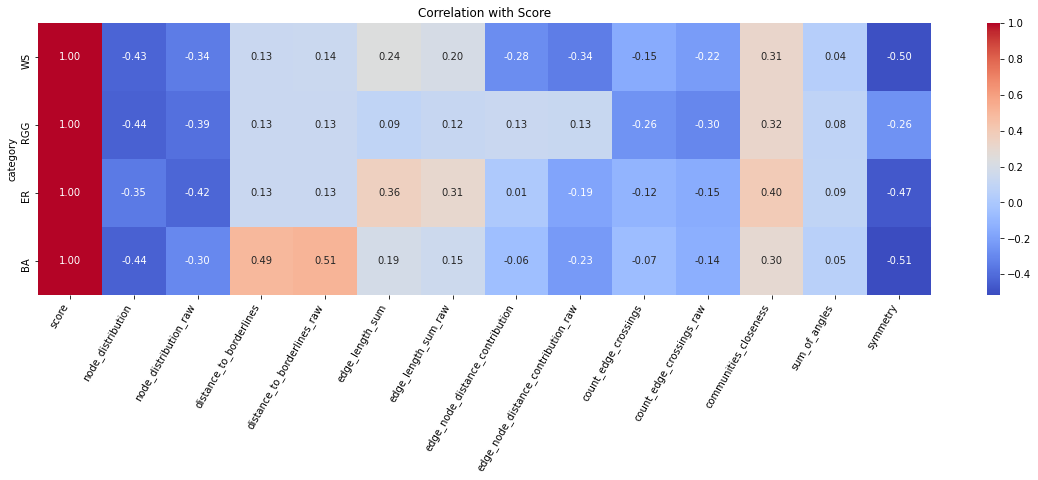

In [9]:
# Plot the heatmap
plt.figure(figsize=(20, 5))  # Adjust the figure size as needed
sns.heatmap(all_cats_corrs, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.xticks(rotation=60, ha='right')
plt.title('Correlation with Score')
plt.show()